# PCAT burn-in strategies

This notebook compares fixed proposal scales, adaptive proposal scales, and likelihood-tempered plus adaptive burn-in on two seeded simulated posterior targets. The correlated Gaussian begins with intentionally undersized steps. The equal-weight bimodal target begins in its negative mode. These controlled targets test sampler behavior and are not observational results.

In [1]:
from IPython.display import Image, display
import pandas as pd

from burn_in_strategies import (
    PROBLEMS,
    STRATEGIES,
    plot_performance_comparison,
    plot_posterior_comparison,
    plot_temperature_schedule,
    run_benchmark,
)

results = run_benchmark(number_sweeps=1200)
rows = []
for problem in PROBLEMS:
    for strategy, options in STRATEGIES.items():
        result = results[(problem, strategy)]
        rows.append(
            {
                "problem": problem,
                "strategy": options["label"],
                "acceptance_fraction": result["acceptance_fraction"],
                "effective_sample_size": result["effective_sample_size"],
                "target_summary_error": result["posterior_error"],
                "runtime_seconds": result["elapsed_seconds"],
            }
        )
metrics = pd.DataFrame(rows)
metrics

Matplotlib is building the font cache; this may take a moment.


,problem,strategy,acceptance_fraction,effective_sample_size,target_summary_error,runtime_seconds
0,correlated_gaussian,Fixed scale,0.912222,4.483161,0.967478,0.348715
1,correlated_gaussian,Adaptive,0.746667,5.048031,0.692360,0.340518
2,correlated_gaussian,Tempered + adaptive,0.562222,11.378237,0.240866,0.332839
3,bimodal,Fixed scale,0.574444,280.748111,0.500000,0.329902
4,bimodal,Adaptive,0.437778,251.683194,0.500000,0.325439
5,bimodal,Tempered + adaptive,0.267778,32.036376,0.008889,0.324794


## Posterior exploration

For the correlated Gaussian, target-summary error is the Euclidean distance between the retained sample mean and the true mean. For the bimodal target, it is the absolute error in the positive-mode posterior weight relative to 0.5.

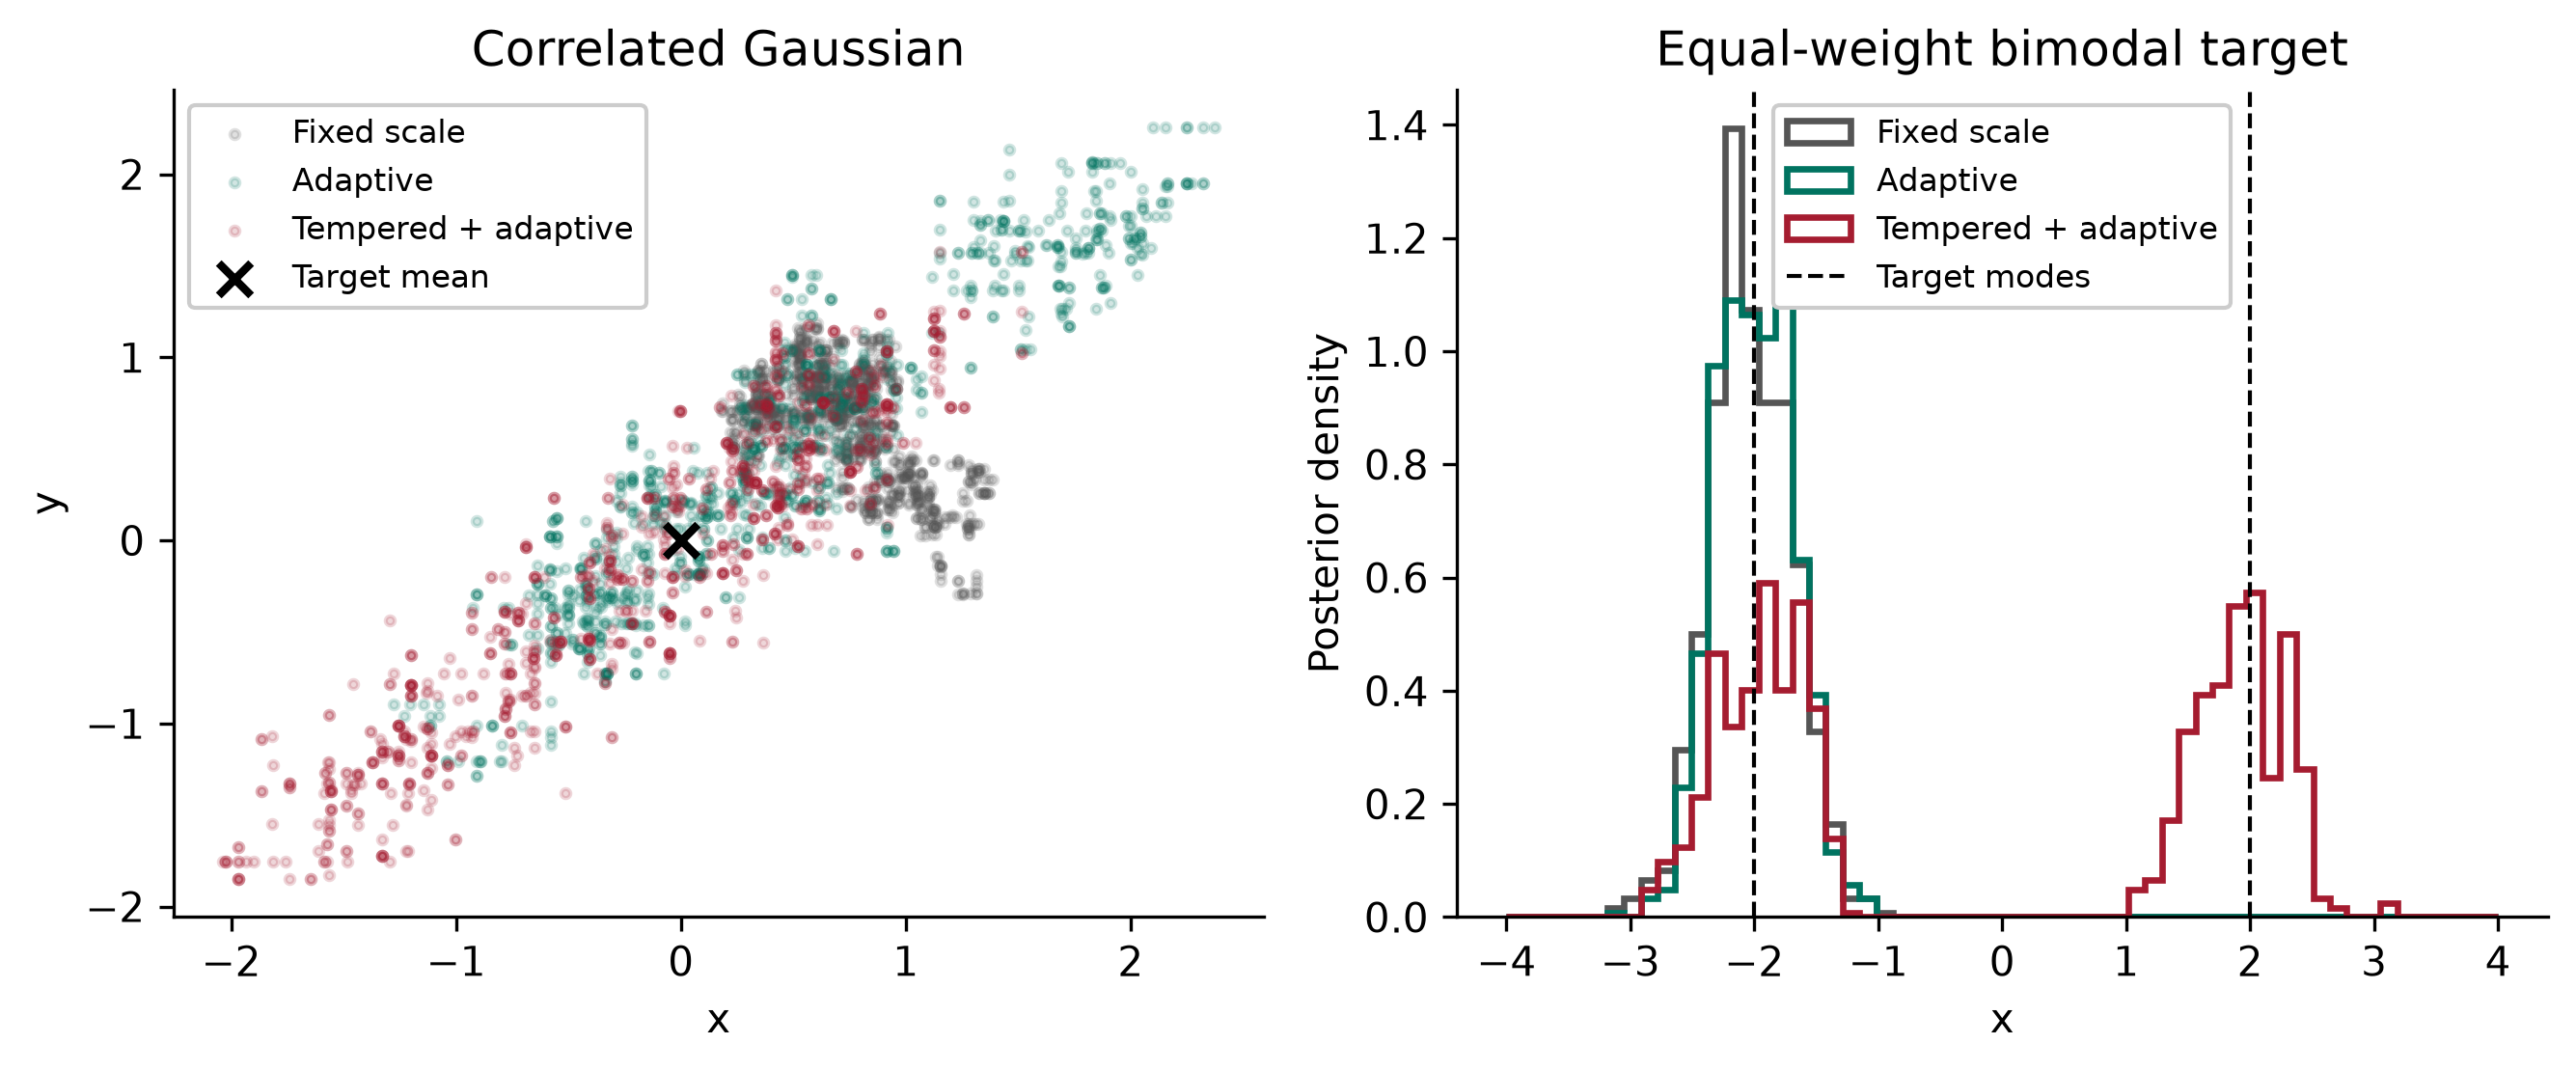

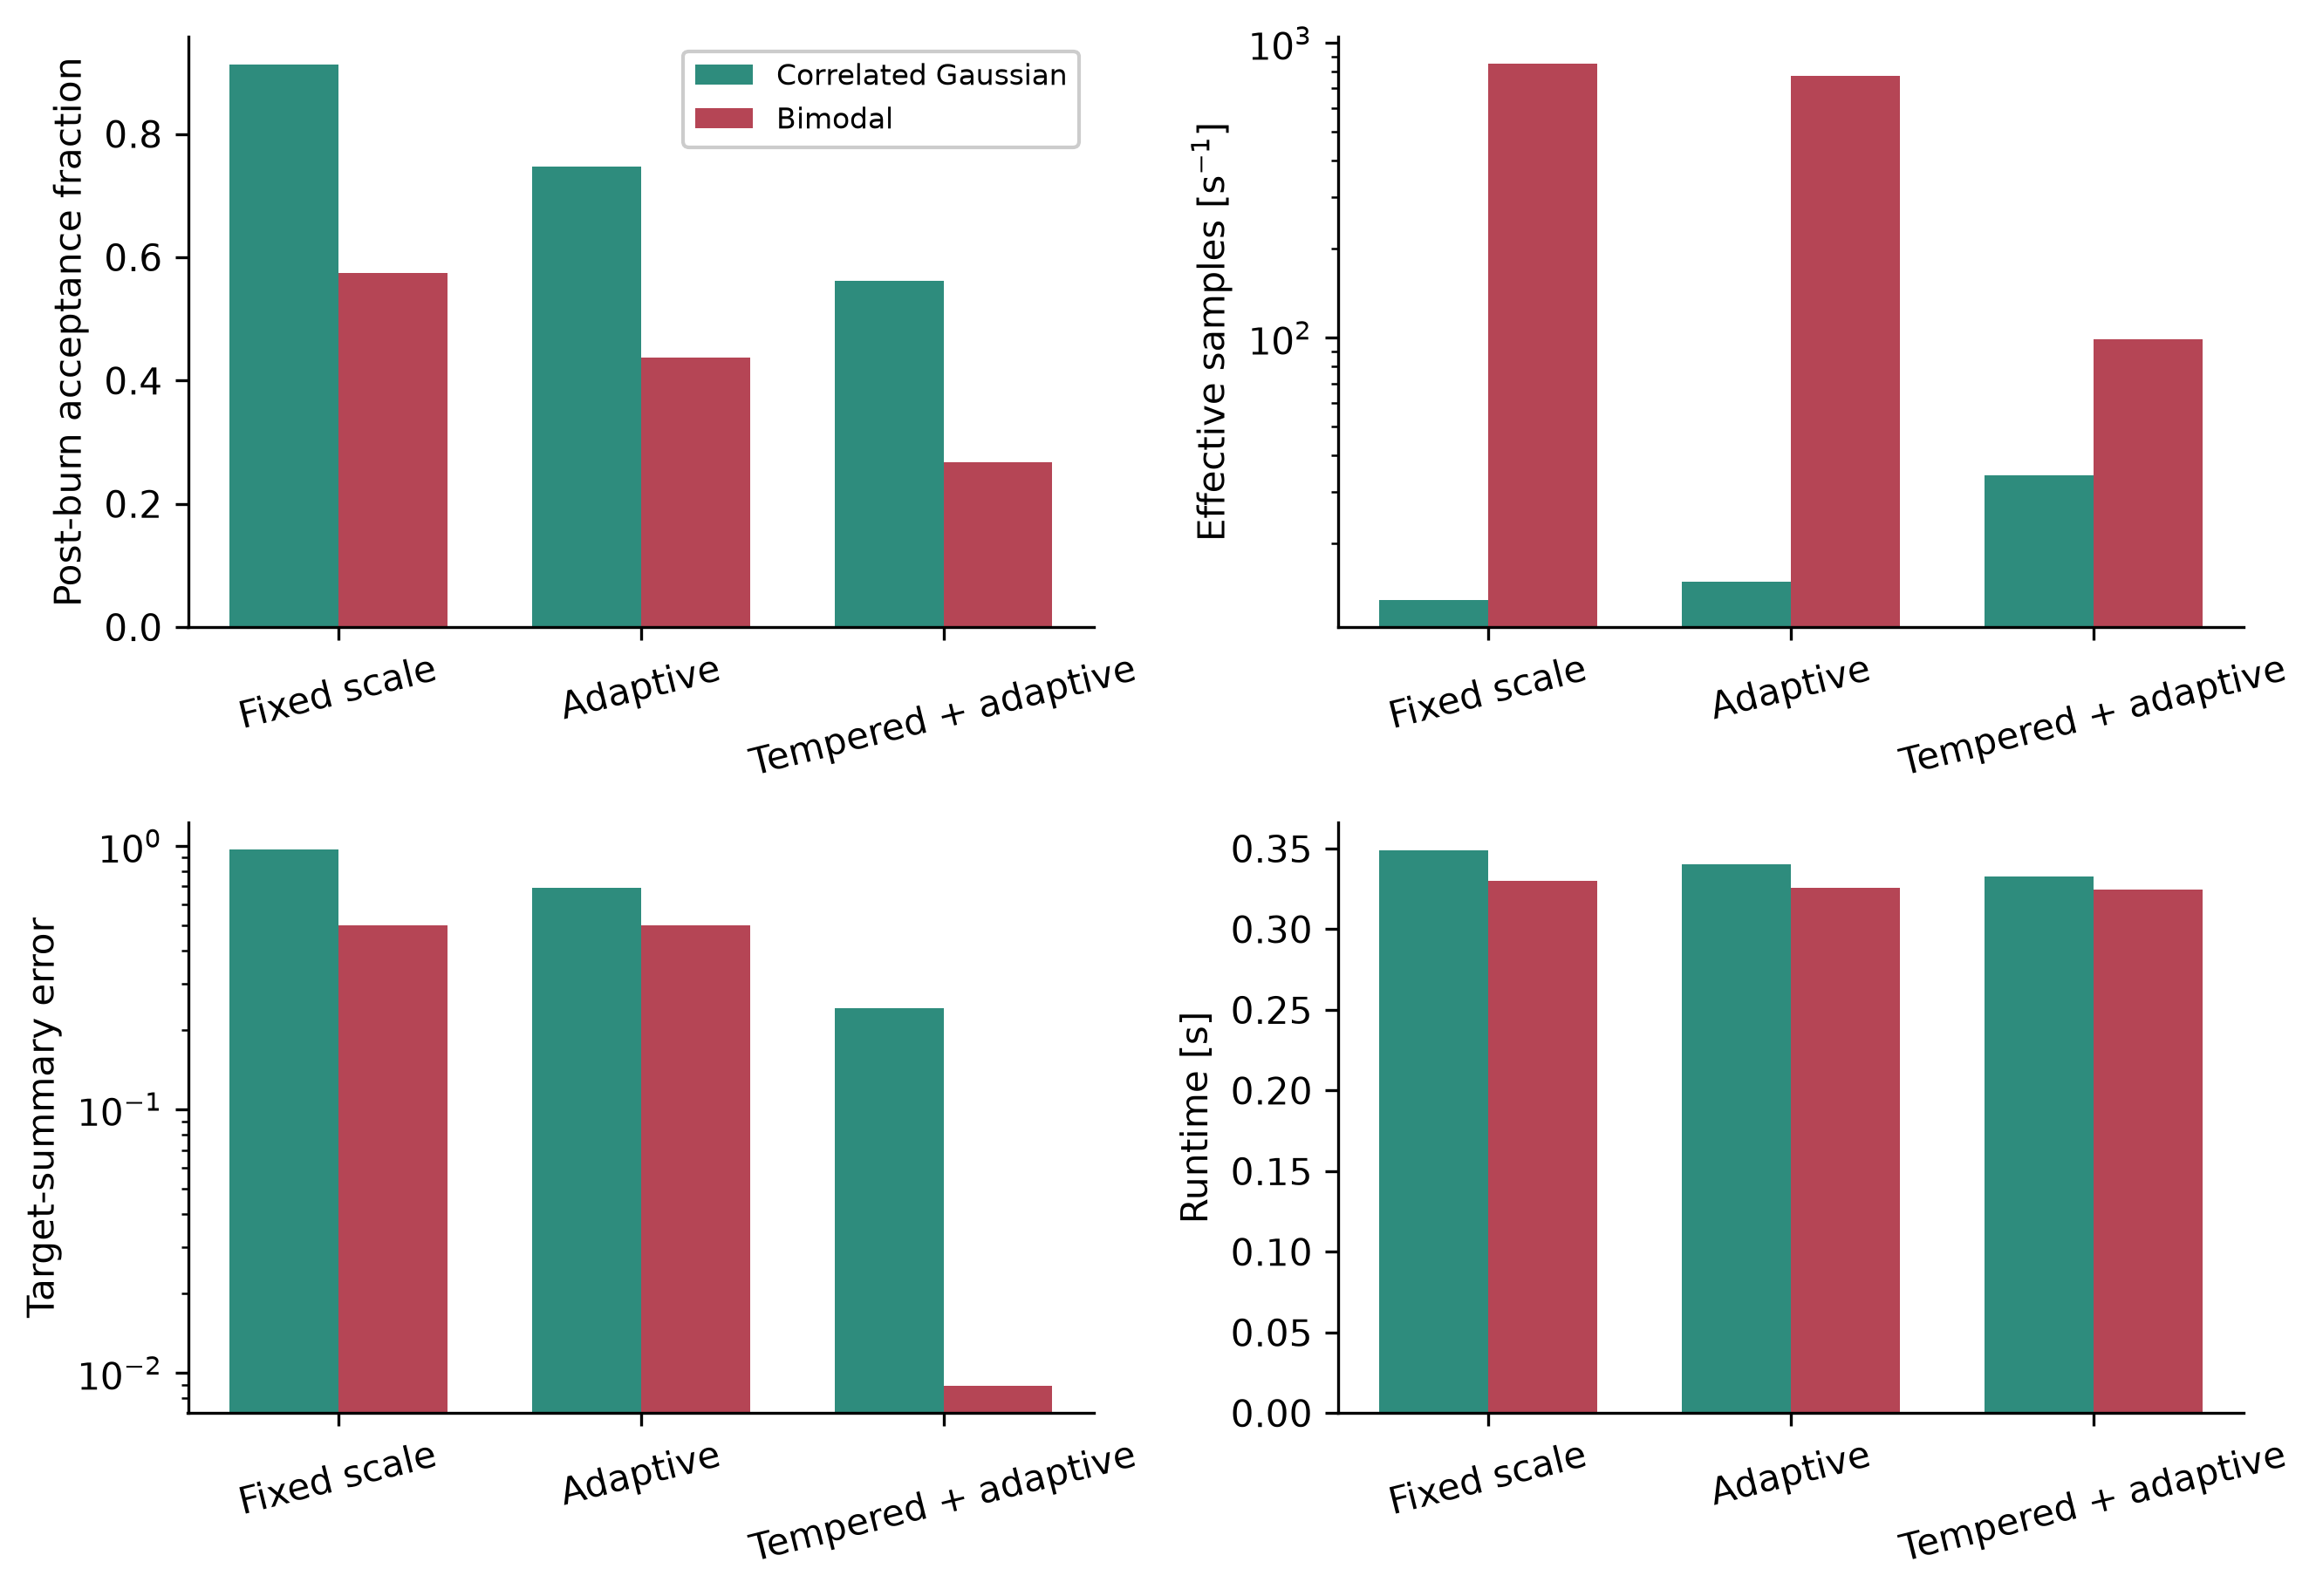

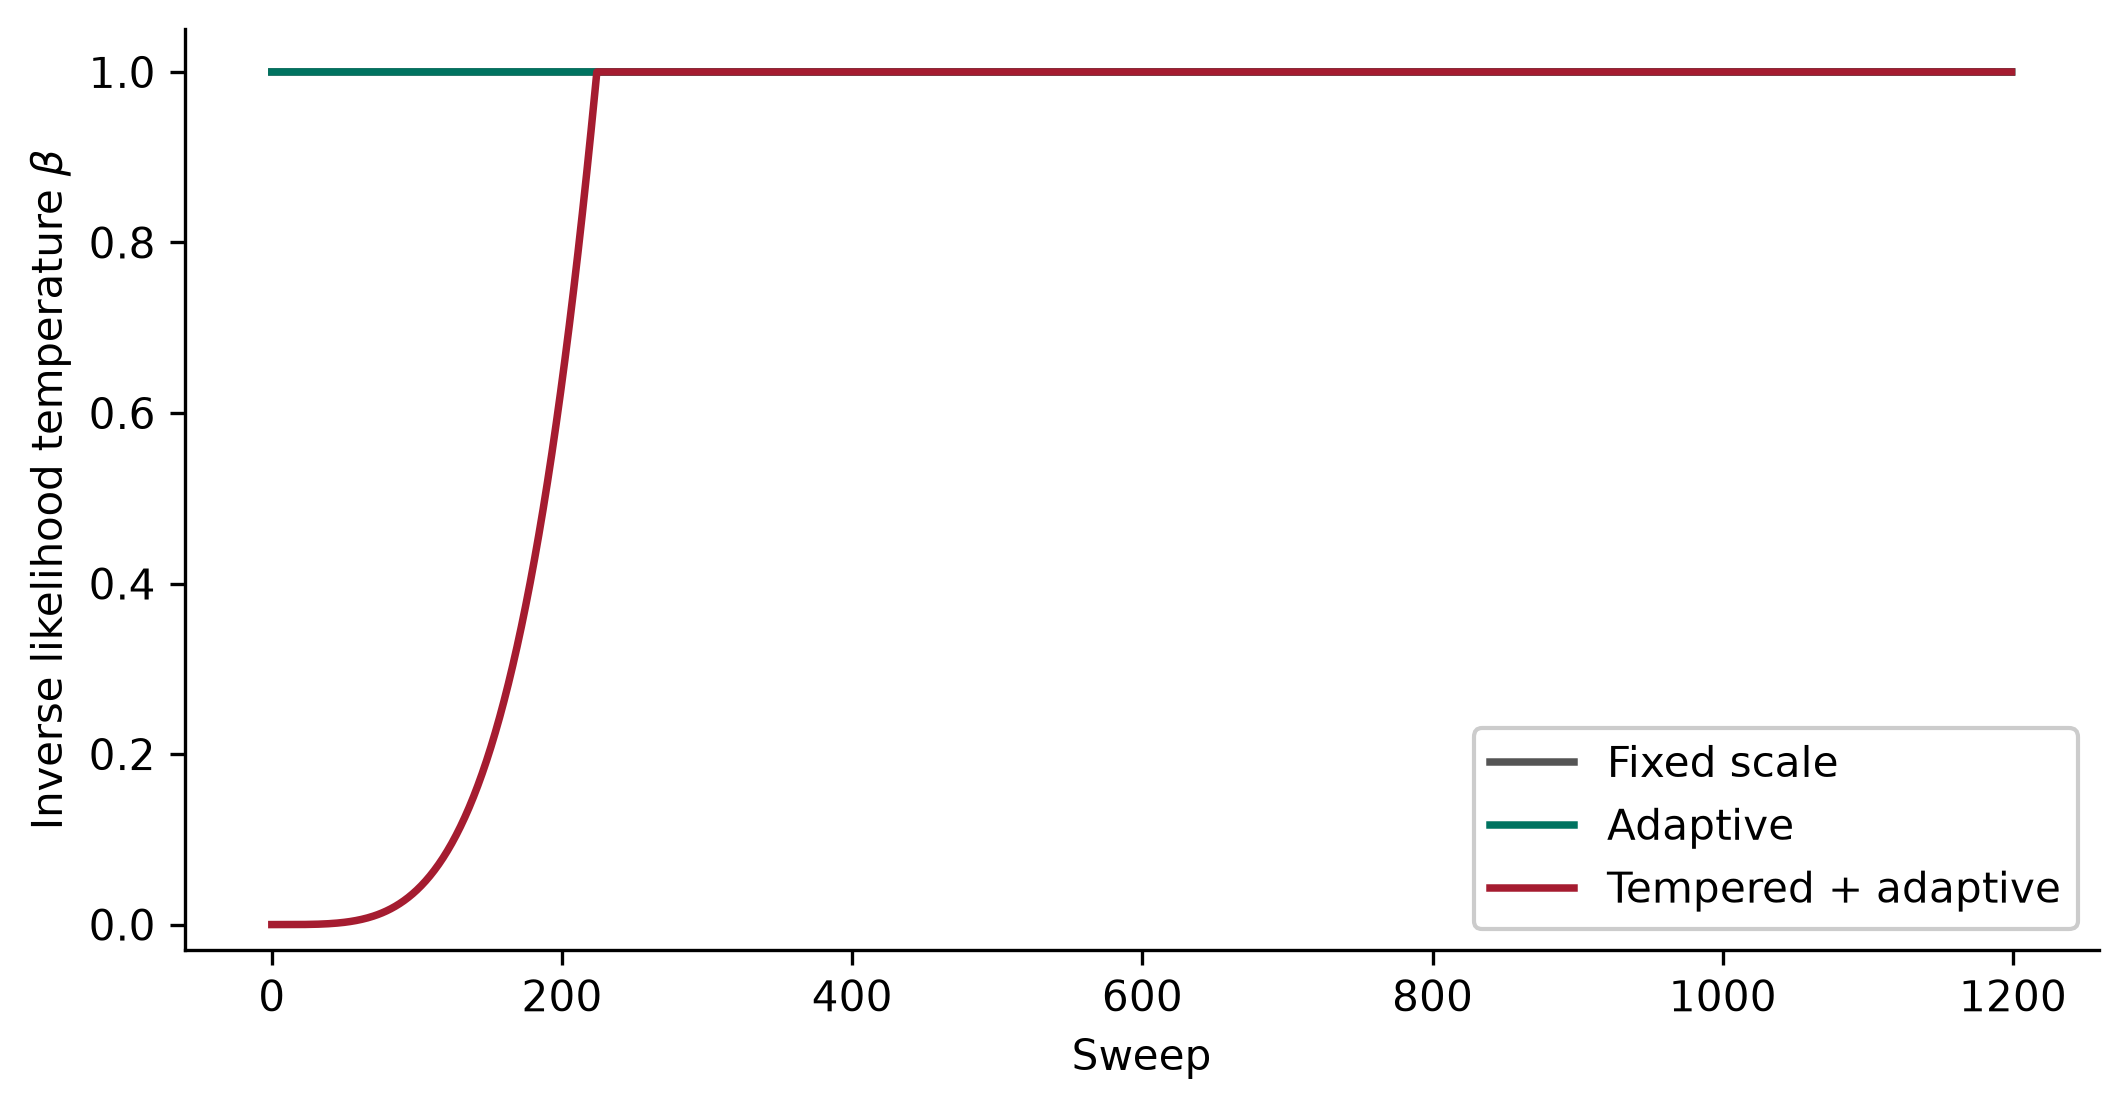

In [2]:
figure_paths = (
    plot_posterior_comparison(results),
    plot_performance_comparison(results),
    plot_temperature_schedule(results),
)
for path in figure_paths:
    display(Image(filename=str(path)))